# **Ambition Box Analysis**

### **Problem Statement**

In today's competitive job market, job seekers and HR professionals 
lack a structured, data-driven understanding of what makes a company 
a great place to work in India. While platforms like AmbitionBox 
collect thousands of employee reviews and ratings, this data remains 
largely unexplored at scale. There is no clear analysis of which 
industries, locations, or company sizes consistently deliver better 
employee satisfaction across key factors like work-life balance, 
career growth, job security, and compensation.

#### **Objective**

This project aims to scrape, clean, and analyze company data from 
AmbitionBox to uncover patterns in employee satisfaction across companies. Specifically, the project seeks to:

1. Identify which industries have the highest and lowest employee ratings
2. Understand how company size impacts overall employee satisfaction
3. Discover which sub-factors (work-life balance, career growth, etc.) 
   drive overall ratings the most
4. Analyze geographic trends — which Indian states and cities have 
   the best-rated companies
5. Examine how company age (founding year) correlates with ratings

The insights from this analysis can help job seekers make informed 
career decisions and help organizations benchmark their employee 
satisfaction against industry standards.

## **Section: 1: Data Collection**

**Importing All the Necessay Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
from bs4 import BeautifulSoup
import time
import random
import json
import warnings
warnings.filterwarnings("ignore")

**Scraping Company Name and Rating**

In [2]:
# Step 1 - Get titles and ratings from listing pages
'''def get_titles():
    titles = []
    ratings = []
    
    user_agents = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/147.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 Safari/605.1.15",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/146.0.0.0 Safari/537.36"]
    custom_headers = {"user-agent": random.choice(user_agents)}

    for page in range(1,10):
        url = f"https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={page}"
        response = requests.get(url,headers=custom_headers)
        soup = BeautifulSoup(response.text,"html.parser")

        for x in soup.find_all("div",attrs={'class':'companyCardWrapper__metaInformation'}):
            title = x.find("h2",attrs={'class':'companyCardWrapper__companyName'})
            rat = x.find("div",attrs={"class":"companyCardWrapper__companyRatingWrapper"})

            titles.append(title.text.strip().replace(" ","-") if title else np.nan)
            ratings.append(rat.text.strip()[0:3] if rat else np.nan)

        time.sleep(random.uniform(2, 5))

    return titles,ratings

title_arr, Ratings = get_titles()'''

'def get_titles():\n    titles = []\n    ratings = []\n\n    user_agents = [\n    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/147.0.0.0 Safari/537.36",\n    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 Safari/605.1.15",\n    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/146.0.0.0 Safari/537.36"]\n    custom_headers = {"user-agent": random.choice(user_agents)}\n\n    for page in range(1,10):\n        url = f"https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={page}"\n        response = requests.get(url,headers=custom_headers)\n        soup = BeautifulSoup(response.text,"html.parser")\n\n        for x in soup.find_all("div",attrs={\'class\':\'companyCardWrapper__metaInformation\'}):\n            title = x.find("h2",attrs={\'class\':\'companyCardWrapper__companyName\'})\n            rat = x.find("div",attrs={"class":"companyCardWrapper__companyRatingWrapper"})\n\n            titles.append(title.text.strip(

**Checking the length of a List Containing all the Company Names**

In [3]:
#print(len(title_arr))

**Scrapping all the Necessay Data**

**Note:**

- To See all top level keys available : Use `print(data["props"]["pageProps"].keys())` , It will list all the available keys 
- For Ex : dict_keys(['userAgent', 'metaData', 'companyMetaInformation', 'companyId', 'benefits', ........... ,'aggregatedRatingsData', 'reviews',])

In [4]:
'''
user_agents = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/147.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 Safari/605.1.15",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/146.0.0.0 Safari/537.36"]

Founded = []
India_Hq_city = []
India_Hq_country = []
Main_Hq_city = []
Main_Hq_country = []
Industry = []
Highly_Rated = []
Critically_Rated = []
Indian_Emp_Count = []
Global_Emp_Count = []
Job_Security_Rating = []
Worklife_Rating = []
Company_Culture_Rating = []
Skill_Dev_Rating = []
Work_Satisfaction_Rating = []
Compensation_Rating = []
Career_Growth_Rating = []

for x in title_arr[0:100]:
    start_time = time.time()
    x = x.replace(" ","-").replace("&","and").replace(".","dot").replace("'","")
    company_url = f"https://www.ambitionbox.com/overview/{x}-overview"

    inner_response = requests.get(company_url, headers={"user-agent": random.choice(user_agents)})
    new_soup = BeautifulSoup(inner_response.text,"html.parser")
    script = new_soup.find("script", attrs={'id':'__NEXT_DATA__'})

    if script:
        try:
            data = json.loads(script.string)
            company_info = data["props"]["pageProps"]["companyMetaInformation"]

            # Extract first
            found = company_info.get("foundedYear", np.nan)
            prim_industry = company_info['primaryIndustry'][0]["name"] if len(company_info.get('primaryIndustry', [])) > 0 else np.nan

            if company_info.get("indiaHQ"):
                i_hq_city = company_info["indiaHQ"].get("cityState", np.nan)
                i_hq_country = company_info["indiaHQ"].get("country", np.nan)
            else:
                i_hq_city = np.nan
                i_hq_country = np.nan

            if company_info.get("hq"):
                g_hq_city = company_info["hq"].get("cityState", np.nan)
                g_hq_country = company_info["hq"].get("country", np.nan)
            else:
                g_hq_city = np.nan
                g_hq_country = np.nan

            ind_emp = company_info.get("indianEmployeeCount", np.nan)
            global_emp = company_info.get("globalEmployeeCount", np.nan)

            # Append all at once
            Founded.append(found)
            Industry.append(prim_industry)
            India_Hq_city.append(i_hq_city)
            India_Hq_country.append(i_hq_country)
            Main_Hq_city.append(g_hq_city)
            Main_Hq_country.append(g_hq_country)
            Indian_Emp_Count.append(ind_emp)
            Global_Emp_Count.append(global_emp)

            # Key Factors
            try:
                ratings = data["props"]["pageProps"]["aggregatedRatingsData"]["ratingDistribution"]["data"]["ratings"]
                Job_Security_Rating.append(ratings["jobSecurityRating"])
                Worklife_Rating.append(ratings["workLifeRating"])
                Company_Culture_Rating.append(ratings["companyCultureRating"])
                Skill_Dev_Rating.append(ratings["skillDevelopmentRating"])
                Work_Satisfaction_Rating.append(ratings["workSatisfactionRating"])
                Compensation_Rating.append(ratings["compensationBenefitsRating"])
                Career_Growth_Rating.append(ratings["careerGrowthRating"])
            except:
                Job_Security_Rating.append(np.nan)
                Worklife_Rating.append(np.nan)
                Company_Culture_Rating.append(np.nan)
                Skill_Dev_Rating.append(np.nan)
                Work_Satisfaction_Rating.append(np.nan)
                Compensation_Rating.append(np.nan)
                Career_Growth_Rating.append(np.nan)

        except Exception as e:
            print(f"KeyError for {x}: {e}")
            Founded.append(np.nan)
            Industry.append(np.nan)
            India_Hq_city.append(np.nan)
            India_Hq_country.append(np.nan)
            Main_Hq_city.append(np.nan)
            Main_Hq_country.append(np.nan)
            Indian_Emp_Count.append(np.nan)
            Global_Emp_Count.append(np.nan)
            Job_Security_Rating.append(np.nan)
            Worklife_Rating.append(np.nan)
            Company_Culture_Rating.append(np.nan)
            Skill_Dev_Rating.append(np.nan)
            Work_Satisfaction_Rating.append(np.nan)
            Compensation_Rating.append(np.nan)
            Career_Growth_Rating.append(np.nan)

    else:
        print(f"No Data Found for {x}")
        Founded.append(np.nan)
        Industry.append(np.nan)
        India_Hq_city.append(np.nan)
        India_Hq_country.append(np.nan)
        Main_Hq_city.append(np.nan)
        Main_Hq_country.append(np.nan)
        Indian_Emp_Count.append(np.nan)
        Global_Emp_Count.append(np.nan)
        Job_Security_Rating.append(np.nan)
        Worklife_Rating.append(np.nan)
        Company_Culture_Rating.append(np.nan)
        Skill_Dev_Rating.append(np.nan)
        Work_Satisfaction_Rating.append(np.nan)
        Compensation_Rating.append(np.nan)
        Career_Growth_Rating.append(np.nan)

    # Highly & Critically Rated
    rated = new_soup.find_all("p", attrs={'class': 'text-sm font-pn-400 text-neutral w-full'})
    Highly_Rated.append(rated[0].text if len(rated) > 0 else None)
    Critically_Rated.append(rated[1].text if len(rated) > 1 else None)

    print(f"Scraping Successful for: {x} in {time.time()-start_time:.2f} seconds.")
    time.sleep(random.uniform(2, 5))
'''

'\nuser_agents = [\n    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/147.0.0.0 Safari/537.36",\n    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 Safari/605.1.15",\n    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/146.0.0.0 Safari/537.36"]\n\nFounded = []\nIndia_Hq_city = []\nIndia_Hq_country = []\nMain_Hq_city = []\nMain_Hq_country = []\nIndustry = []\nHighly_Rated = []\nCritically_Rated = []\nIndian_Emp_Count = []\nGlobal_Emp_Count = []\nJob_Security_Rating = []\nWorklife_Rating = []\nCompany_Culture_Rating = []\nSkill_Dev_Rating = []\nWork_Satisfaction_Rating = []\nCompensation_Rating = []\nCareer_Growth_Rating = []\n\nfor x in title_arr[0:100]:\n    start_time = time.time()\n    x = x.replace(" ","-").replace("&","and").replace(".","dot").replace("\'","")\n    company_url = f"https://www.ambitionbox.com/overview/{x}-overview"\n\n    inner_response = requests.get(company_url, headers={"user-agent": random.choice(user_agen

In [5]:
# Step 3 - Build DataFrame
'''
df = pd.DataFrame({
    "Company": title_arr[0:100],
    "Ratings": Ratings[0:100],
    "Founded": Founded,
    "Indian_Headquarter_City": India_Hq_city,
    "Indian_Headquarter_Country": India_Hq_country,
    "Main_Headquarter_City": Main_Hq_city,
    "Main_Headquarter_Country": Main_Hq_country,
    "Indian_Employee_Count": Indian_Emp_Count,
    "Global_Employee_Count": Global_Emp_Count,
    "Industry": Industry,
    "Highly_Rated": Highly_Rated,
    "Critically_Rated": Critically_Rated,
    "Job_Security_Rating":Job_Security_Rating,
    "WorkLife_Rating":Worklife_Rating,
    "Company_Culture_Rating":Company_Culture_Rating,
    "Skill_Development_Rating":Skill_Dev_Rating,
    "Work_Satisfaction_Rating":Work_Satisfaction_Rating,
    "Compensation_Rating":Compensation_Rating,
    "Career_Growth_Rating":Career_Growth_Rating,
})
'''


'\ndf = pd.DataFrame({\n    "Company": title_arr[0:100],\n    "Ratings": Ratings[0:100],\n    "Founded": Founded,\n    "Indian_Headquarter_City": India_Hq_city,\n    "Indian_Headquarter_Country": India_Hq_country,\n    "Main_Headquarter_City": Main_Hq_city,\n    "Main_Headquarter_Country": Main_Hq_country,\n    "Indian_Employee_Count": Indian_Emp_Count,\n    "Global_Employee_Count": Global_Emp_Count,\n    "Industry": Industry,\n    "Highly_Rated": Highly_Rated,\n    "Critically_Rated": Critically_Rated,\n    "Job_Security_Rating":Job_Security_Rating,\n    "WorkLife_Rating":Worklife_Rating,\n    "Company_Culture_Rating":Company_Culture_Rating,\n    "Skill_Development_Rating":Skill_Dev_Rating,\n    "Work_Satisfaction_Rating":Work_Satisfaction_Rating,\n    "Compensation_Rating":Compensation_Rating,\n    "Career_Growth_Rating":Career_Growth_Rating,\n})\n'

In [6]:
#df.tail()

In [7]:
# df.to_csv("Batch_06.csv",index=False)

In [8]:
# final = pd.concat([pd.read_csv("Batch_01.csv"),pd.read_csv("Batch_02.csv"),pd.read_csv("Batch_03.csv"),pd.read_csv("Batch_04.csv"),pd.read_csv("Batch_05.csv"),pd.read_csv("Batch_06.csv")])

In [9]:
# final.to_csv("Company_Data.csv",index=False)

# **Section - 2: EXPLORATORY DATA ANALYSIS**

**Loading the Scrapped Dataset**

In [10]:
company_df = pd.read_csv("Company_Data.csv")
company_df.head()

,Company,Ratings,Founded,Indian_Headquarter_City,Indian_Headquarter_Country,Main_Headquarter_City,Main_Headquarter_Country,Indian_Employee_Count,Global_Employee_Count,Industry,Highly_Rated,Critically_Rated,Job_Security_Rating,WorkLife_Rating,Company_Culture_Rating,Skill_Development_Rating,Work_Satisfaction_Rating,Compensation_Rating,Career_Growth_Rating
0,TCS,3.3,1968.0,"Mumbai, Maharashtra",India,"Mumbai, Maharashtra",India,607979.0,100001+,IT Services & Consulting,Job security,"Promotions, Salary, Work satisfaction",3.9,3.5,3.2,3.2,3.0,2.5,2.3
1,Accenture,3.7,1989.0,NaN,NaN,Dublin,Ireland,350000.0,100001+,IT Services & Consulting,"Promotions, Salary",NaN,3.6,3.6,3.7,3.6,3.4,3.3,2.8
2,Wipro,3.6,1945.0,"Bangalore/Bengaluru, Karnataka",India,"Bangalore/Bengaluru, Karnataka",India,233346.0,100001+,IT Services & Consulting,"Promotions, Salary",NaN,3.7,3.6,3.6,3.5,3.4,3.0,2.9
3,Cognizant,3.7,1994.0,NaN,NaN,Teaneck. New Jersey.,United States (USA),241500.0,100001+,IT Services & Consulting,"Promotions, Salary",NaN,3.6,3.6,3.6,3.6,3.4,3.2,2.9
4,Capgemini,3.6,1967.0,"Mumbai, Maharashtra",India,"Paris, France",NaN,235000.0,100001+,IT Services & Consulting,"Job security, Work-life balance","Promotions, Salary",3.8,3.8,3.6,3.6,3.4,3.0,2.8


### **2.1 Data Understanding**

**Checking the all the information about our dataset**

In [11]:
company_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company                     2000 non-null   str    
 1   Ratings                     2000 non-null   float64
 2   Founded                     1704 non-null   float64
 3   Indian_Headquarter_City     1322 non-null   str    
 4   Indian_Headquarter_Country  1332 non-null   str    
 5   Main_Headquarter_City       1689 non-null   str    
 6   Main_Headquarter_Country    1601 non-null   str    
 7   Indian_Employee_Count       1755 non-null   float64
 8   Global_Employee_Count       1702 non-null   str    
 9   Industry                    1766 non-null   str    
 10  Highly_Rated                1529 non-null   str    
 11  Critically_Rated            547 non-null    str    
 12  Job_Security_Rating         1773 non-null   float64
 13  WorkLife_Rating             1773 non-null   

**Checking Rows and columns**

In [12]:
company_df.shape

(2000, 19)

### **2.2 Checking For Null Values**

In [13]:
company_df.isna().sum()

Company                          0
Ratings                          0
Founded                        296
Indian_Headquarter_City        678
Indian_Headquarter_Country     668
Main_Headquarter_City          311
Main_Headquarter_Country       399
Indian_Employee_Count          245
Global_Employee_Count          298
Industry                       234
Highly_Rated                   471
Critically_Rated              1453
Job_Security_Rating            227
WorkLife_Rating                227
Company_Culture_Rating         227
Skill_Development_Rating       227
Work_Satisfaction_Rating       227
Compensation_Rating            227
Career_Growth_Rating           227
dtype: int64

### **2.3 Dropping the Null values based on Columns**

In [14]:
company_df = company_df.dropna(subset=["Founded","Job_Security_Rating","WorkLife_Rating","Company_Culture_Rating","Skill_Development_Rating",\
                                       "Work_Satisfaction_Rating","Compensation_Rating","Career_Growth_Rating","Industry","Indian_Employee_Count","Global_Employee_Count"])

In [15]:
company_df.drop(columns=["Critically_Rated","Highly_Rated","Indian_Headquarter_Country"],inplace=True)

### **2.4 Checking For Duplicates**

In [16]:
company_df.duplicated().sum()

np.int64(11)

**Removing Duplicate Values**

In [17]:
company_df = company_df.drop_duplicates()

# Checking Again to verify
company_df.duplicated().sum()

np.int64(0)

### **2.5 CLeaning Headquarter columns for Both India and Global**

**Splitting the `Indian_Headquarter_City` columns data into seperate columns containing City Name and State**

- ex : we have this as our one Entry : `Bangalore/Bengaluru, Karnataka`
- First we split on the basis of `,`
- Again split on the basis of `/`
- Selecting the values based on the indexing

In [18]:
company_df["India_Hq_City"] = company_df["Indian_Headquarter_City"].str.split(",").str[0]
company_df["India_Hq_City"] = company_df["India_Hq_City"].str.split("/").str[0]

company_df["India_Hq_State"] = company_df["Indian_Headquarter_City"].str.split(",").str[1]

**Now Replacing the Null values with nan**

- In future when we plot the Graphs, these values will be skipped by Default

In [19]:
company_df["India_Hq_City"] = company_df["India_Hq_City"].fillna("No Headquarter")
company_df["India_Hq_State"] = company_df["India_Hq_State"].fillna("No Headquarter")

**Splitting the `Main_Headquarter_City` columns data into seperate columns containing City Name and State**

In [20]:
company_df["Main_Hq_Split"] = company_df["Main_Headquarter_City"].str.split(",")

In [21]:
company_df["Main_Hq_City"] = company_df["Main_Hq_Split"].str[0]
company_df["Main_Hq_State"] = company_df["Main_Hq_Split"].str[1]

**Replacing the Null Values with np.nan to Preserve the data**

In [22]:
company_df["Main_Hq_City"] = company_df["Main_Hq_City"].fillna("No Headquarter")
company_df["Main_Hq_State"] = company_df["Main_Hq_State"].fillna("No Headquarter")

In [23]:
# company_df.isna().sum()

**Replacing Values inside `Main_Headquarter_Country`**

In [24]:
company_df["Main_Headquarter_Country"] = company_df["Main_Headquarter_Country"].fillna("Not Provided")

**Removing the `Indian_Headquarter_City`, `Main_Headquarter_City` and `Main_Hq_Split` Columns**

In [25]:
company_df.drop(columns=["Indian_Headquarter_City","Main_Headquarter_City","Main_Hq_Split"],inplace=True)

In [26]:
company_df.isna().sum()

Company                     0
Ratings                     0
Founded                     0
Main_Headquarter_Country    0
Indian_Employee_Count       0
Global_Employee_Count       0
Industry                    0
Job_Security_Rating         0
WorkLife_Rating             0
Company_Culture_Rating      0
Skill_Development_Rating    0
Work_Satisfaction_Rating    0
Compensation_Rating         0
Career_Growth_Rating        0
India_Hq_City               0
India_Hq_State              0
Main_Hq_City                0
Main_Hq_State               0
dtype: int64

In [27]:
company_df.head()

,Company,Ratings,Founded,Main_Headquarter_Country,Indian_Employee_Count,Global_Employee_Count,Industry,Job_Security_Rating,WorkLife_Rating,Company_Culture_Rating,Skill_Development_Rating,Work_Satisfaction_Rating,Compensation_Rating,Career_Growth_Rating,India_Hq_City,India_Hq_State,Main_Hq_City,Main_Hq_State
0,TCS,3.3,1968.0,India,607979.0,100001+,IT Services & Consulting,3.9,3.5,3.2,3.2,3.0,2.5,2.3,Mumbai,Maharashtra,Mumbai,Maharashtra
1,Accenture,3.7,1989.0,Ireland,350000.0,100001+,IT Services & Consulting,3.6,3.6,3.7,3.6,3.4,3.3,2.8,No Headquarter,No Headquarter,Dublin,No Headquarter
2,Wipro,3.6,1945.0,India,233346.0,100001+,IT Services & Consulting,3.7,3.6,3.6,3.5,3.4,3.0,2.9,Bangalore,Karnataka,Bangalore/Bengaluru,Karnataka
3,Cognizant,3.7,1994.0,United States (USA),241500.0,100001+,IT Services & Consulting,3.6,3.6,3.6,3.6,3.4,3.2,2.9,No Headquarter,No Headquarter,Teaneck. New Jersey.,No Headquarter
4,Capgemini,3.6,1967.0,Not Provided,235000.0,100001+,IT Services & Consulting,3.8,3.8,3.6,3.6,3.4,3.0,2.8,Mumbai,Maharashtra,Paris,France


### **2.6 Fixing the Datatypes of our columns**

From our Dataset we can clearly see:
- `Founded` , `Indian_Employee_Count` has float Datatype but we want this as Integers. 
- `Indian_Hq_City`,`Indian_Hq_State`,`Main_Hq_City`,`Main_Hq_State` has object Datatype but we want this as String

In [28]:
# company_df.info()

**Fixing Dtyeps of the Headquarter Related Columns**

In [29]:
col = ['India_Hq_City','India_Hq_State','Main_Hq_City','Main_Hq_State']
for x in col:
    company_df[col] = company_df[col].astype("str")

**Fixing Dtyeps of Founded and Indian Employee count Columns**

In [30]:
col = ["Founded","Indian_Employee_Count"] 
for x in col:
    company_df[col] = company_df[col].astype("int")

### **2.7 Creating the Indian Employee Count range using `Indian_Employee_Count`**

In [31]:
bins = [0, 50, 200, 500, 1000, 5000, 10000, 50000, 100000, float('inf')]
labels = ["1-50", "51-200", "201-500", "501-1000", "1k-5k", "5k-10k", "10k-50k", "50k-100k", "100k+"]

company_df["Ind_Emp_Size_Range"] = pd.cut(company_df["Indian_Employee_Count"], bins=bins, labels=labels)

print(company_df["Ind_Emp_Size_Range"].value_counts().sort_index())

Ind_Emp_Size_Range
1-50          2
51-200        8
201-500      28
501-1000     80
1k-5k       914
5k-10k      252
10k-50k     287
50k-100k     33
100k+        38
Name: count, dtype: int64


### **2.8 Fixing the Duplication of State Names**

In [32]:
state_fix = {
    "New Delhi": "Delhi",
    "Gujrat": "Gujarat",
    "NCT": "Delhi",
    "Navi Mumbai": "Maharashtra",
    "India": np.nan,
    "England": np.nan,
    "California": np.nan,
    "United States": np.nan,
    "Union Territory Of Chandigarh": "Punjab",
    "Kanpur": "Uttar Pradesh",
    "Uttarpradesh": "Uttar Pradesh",
    "Harayana": "Haryana",
    "Tamilnadu": "Tamil Nadu",
    "rajasthan": "Rajasthan",
    "No Headquarter": np.nan
}

company_df["India_Hq_State"] = company_df["India_Hq_State"].replace(state_fix).str.strip()

In [33]:
company_df["India_Hq_State"] = company_df["India_Hq_State"].replace(state_fix).str.strip()

### **2.9 Creating New columns by using Founded Years for Decades**

In [34]:
company_df["Decade"] = (company_df["Founded"] // 10) * 10


**Cleaning the Global Hq Details**

In [109]:
company_df['Main_Headquarter_Country'] = company_df['Main_Headquarter_Country'].replace({
    'United States (USA)': 'United States',
    'UnitedStates':'United States',
    'US':'United States',
    'USA':'United States',
    'United Kingdom (UK)':'United Kingdom',
    'UnitedKingdom': 'United Kingdom'
})

# Remove missing values if any
company_df = company_df.dropna(subset=['Main_Headquarter_Country'])

**Verifying again to check if the Datatypes is Changed or Not**

In [35]:
company_df.info()

<class 'pandas.DataFrame'>
Index: 1642 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Company                   1642 non-null   str     
 1   Ratings                   1642 non-null   float64 
 2   Founded                   1642 non-null   int64   
 3   Main_Headquarter_Country  1642 non-null   str     
 4   Indian_Employee_Count     1642 non-null   int64   
 5   Global_Employee_Count     1642 non-null   str     
 6   Industry                  1642 non-null   str     
 7   Job_Security_Rating       1642 non-null   float64 
 8   WorkLife_Rating           1642 non-null   float64 
 9   Company_Culture_Rating    1642 non-null   float64 
 10  Skill_Development_Rating  1642 non-null   float64 
 11  Work_Satisfaction_Rating  1642 non-null   float64 
 12  Compensation_Rating       1642 non-null   float64 
 13  Career_Growth_Rating      1642 non-null   float64 
 14  India_Hq

# **Section 3: Insights**

### **3.1 Understanding the Data (Univariate Analysis)**

#### **3.1.1 What is the Distribution of Overall Rating**

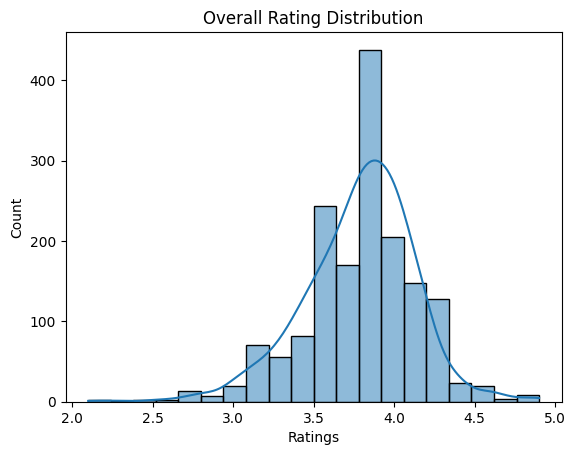

In [36]:
plt.title("Overall Rating Distribution")
ax = sns.histplot(x="Ratings",data = company_df,bins=20,kde=True)
plt.show()

**Insights:**

- The majority of companies on AmbitionBox are rated between 3.5 and 4.2, with the peak around 3.9-4.0.
- Very few companies fall below 3.0, suggesting that poorly rated companies either don't appear on AmbitionBox or receive fewer reviews.

#### **3.1.2 Which Industy has the most number of companies (Top-15)**

In [37]:
company_industry = company_df["Industry"].value_counts().head(15)
company_industry

Industry
IT Services & Consulting      214
Auto Components                91
Engineering & Construction     73
Pharma                         65
NBFC                           62
Internet                       60
Software Product               57
BPO                            55
Financial Services             55
Industrial Machinery           45
Banking                        42
Building Material              38
Retail                         37
Automobile                     36
Insurance                      36
Name: count, dtype: int64

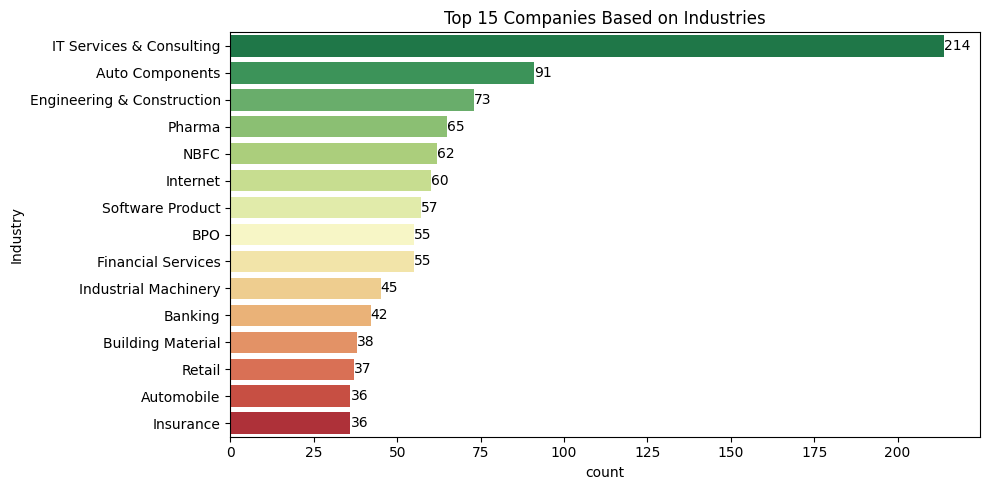

In [38]:
plt.figure(figsize=(10,5))
plt.title("Top 15 Companies Based on Industries")
sns.barplot(x=company_industry,y=company_industry.index,palette="RdYlGn_r")

for container in plt.gca().containers:
    plt.bar_label(container)
plt.tight_layout()
plt.show()

**Insights:**

- IT Services & Consulting dominates with 214 companies — more than double the second place
- Auto Components (91) being second shows India's strong manufacturing sector presence
- Engineering & Construction (73) reflects India's ongoing infrastructure boom
- NBFC, Banking & Financial Services all in top 10 — India's financial sector is heavily represented
- BPO (55) confirms India's outsourcing industry is still going strong
- IT related industries (IT Services + Software Product + Internet) combined = 331 companies — nearly 21% of entire dataset

#### **3.1.3 What is the Distribution of Company size in India**

In [39]:
ind_emp_size = company_df["Ind_Emp_Size_Range"].value_counts()
ind_emp_size

Ind_Emp_Size_Range
1k-5k       914
10k-50k     287
5k-10k      252
501-1000     80
100k+        38
50k-100k     33
201-500      28
51-200        8
1-50          2
Name: count, dtype: int64

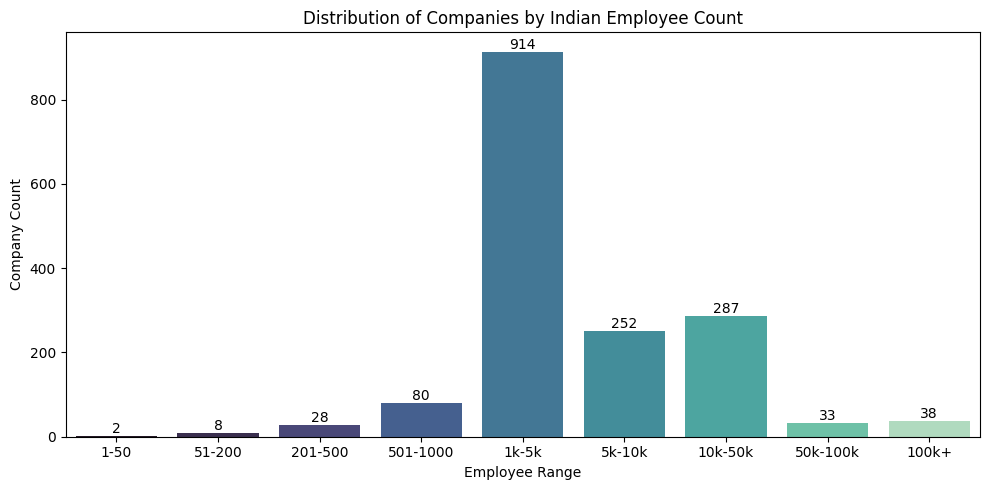

In [40]:
plt.figure(figsize=(10,5))
plt.title("Distribution of Companies by Indian Employee Count")
sns.barplot(x=ind_emp_size.index,y=ind_emp_size,palette="mako")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.xlabel("Employee Range")
plt.ylabel("Company Count")
plt.tight_layout()

**Insights:**

- 1k-5k dominates with 914 companies — majority of companies on AmbitionBox are mid-sized
- 10k-50k (287) and 5k-10k (252) are second and third — large companies are well represented
- Very few small companies (1-50: 2, 51-200: 8) — small businesses rarely appear on AmbitionBox
- 100k+ has 38 companies — India's largest employers like TCS, Infosys, Wipro are a small but important group
- Overall the dataset is skewed towards mid to large sized companies

#### **3.1.4 Which Top-15 Indian state has the most company HQs**

In [41]:
top_15_state = company_df[company_df["India_Hq_State"] != "No Headquarter"]["India_Hq_State"].value_counts().head(15)
# top_15_state

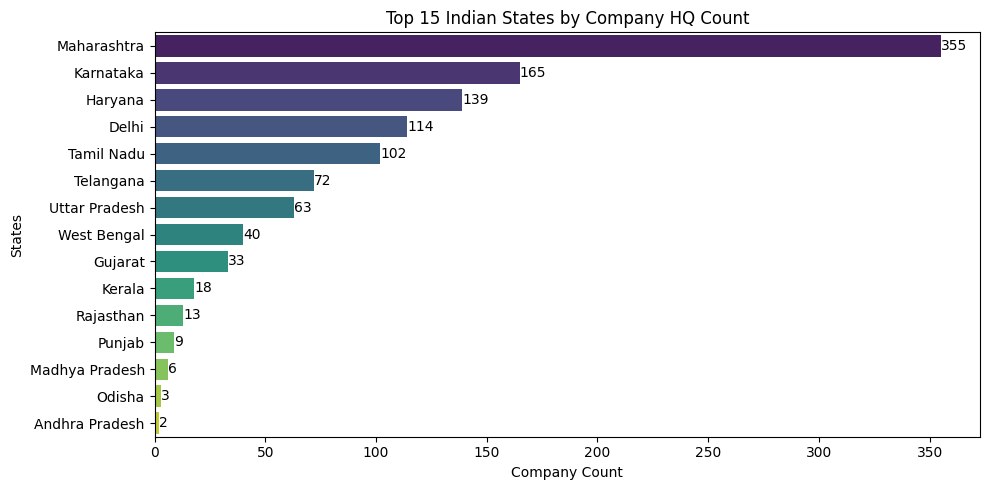

In [42]:
plt.figure(figsize=(10,5))
plt.title("Top 15 Indian States by Company HQ Count")
sns.barplot(x=top_15_state,y=top_15_state.index,palette="viridis")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.ylabel("States")
plt.xlabel("Company Count")
plt.tight_layout()
plt.show()

**Insights:**

- Maharashtra dominates with 355 companies — home to Mumbai, India's financial capital
- Karnataka (165) is second — driven by Bengaluru, India's IT hub
- Haryana (139) third — Gurugram's massive corporate presence explains this
- Delhi (114) fourth — NCR region is a major business corridor
- Tamil Nadu (102) fifth — Chennai's strong manufacturing and IT base
- Telangana (72) — Hyderabad's growing tech ecosystem is reflected here
- Top 5 states alone account for 875 companies — over 54% of the dataset
- South India (Karnataka + Tamil Nadu + Telangana + Kerala) combined = 357 companies — slightly more than Maharashtra alone
- Gujarat (33) surprisingly low despite being a major business state — suggests AmbitionBox skews towards IT/service companies over manufacturing


#### **3.1.5 How has company founding trend changed over decades**

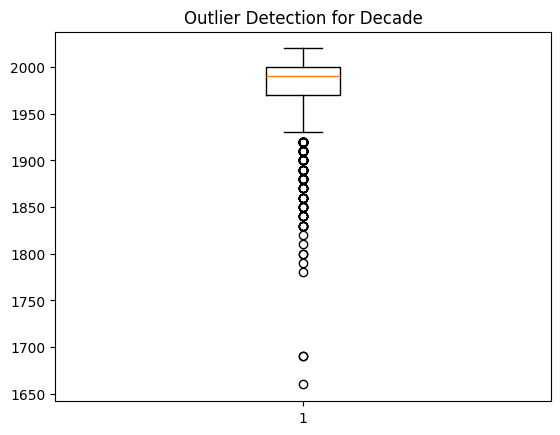

In [43]:
plt.title("Outlier Detection for Decade")
plt.boxplot(company_df.Decade)
plt.show()

- From the above box plot we can see there are lots of outliers below 1900
- So we will filter those outliers for better results

In [57]:
dec = company_df.Decade.value_counts().sort_index()
dec = dec[dec.index >= 1900]
dec

Decade
1900     21
1910     27
1920     33
1930     36
1940     62
1950     59
1960     77
1970     98
1980    206
1990    341
2000    348
2010    233
2020     16
Name: count, dtype: int64

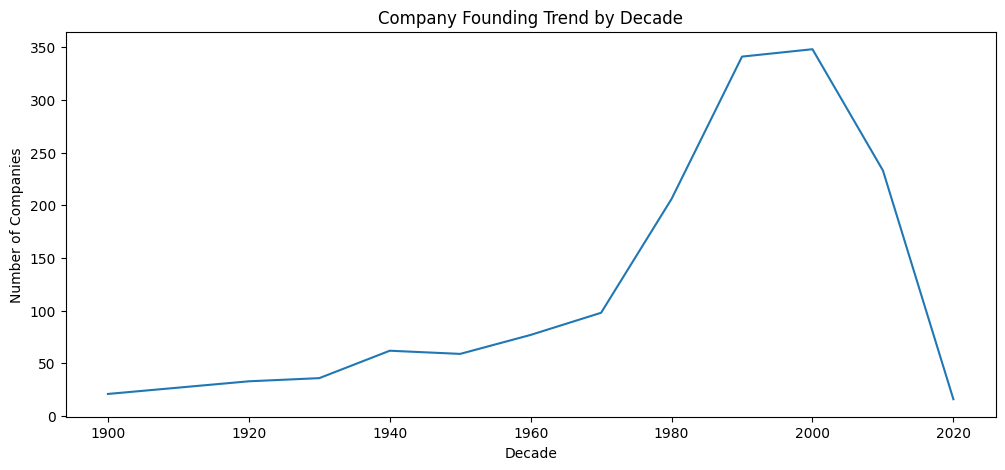

In [45]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=dec.index,y=dec.values)
plt.title("Company Founding Trend by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Companies")
plt.show()

**Insights:**

- 
- 

### **3.2 Rating Deep Dive (Bivariate Analysis)**

#### **3.2.1 Which Industy has Highest and Lowest Overall Rating**

In [46]:
industry_rating = company_df.groupby("Industry")["Ratings"].mean().sort_values()

In [47]:
top_bottom = pd.concat([industry_rating.head(5),industry_rating.tail(5)])
# top_bottom

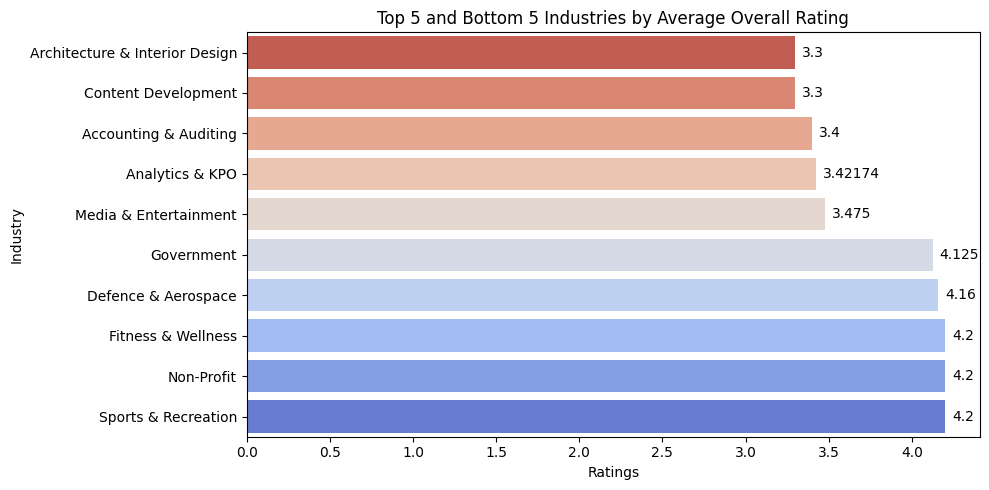

In [48]:
plt.figure(figsize=(10,5))
plt.title("Top 5 and Bottom 5 Industries by Average Overall Rating")
sns.barplot(x=top_bottom,y=top_bottom.index,palette="coolwarm_r")

for container in plt.gca().containers:
    plt.bar_label(container,padding=5)

plt.tight_layout()
plt.show()

**Insights:**

- The highest-rated industries are Sports & Recreation, Non-Profit, and Fitness & Wellness, all with ratings around 4.2, indicating high employee satisfaction.
- Defence & Aerospace and Government sectors also show strong ratings, suggesting that job security and stability play an important role in satisfaction.
- The lowest-rated industries are Architecture & Interior Design and Content Development, both around 3.3, showing comparatively lower employee satisfaction.
- Accounting & Auditing and Analytics & KPO fall in the lower-mid range, indicating average work conditions.
- There is a noticeable gap between top and bottom industries (~0.9 difference), showing that industry choice significantly affects employee experience.
- Overall, non-corporate and stability-focused sectors tend to perform better in employee satisfaction compared to high-pressure or deadline-driven industries.

#### **3.2.2 Which sub-rating is highest and lowest on average**

In [49]:
rating_cols = [
    'Job_Security_Rating', 'WorkLife_Rating', 'Company_Culture_Rating',
    'Skill_Development_Rating', 'Work_Satisfaction_Rating',
    'Compensation_Rating', 'Career_Growth_Rating'
]

sub_rat_mean = company_df[rating_cols].mean().sort_values()


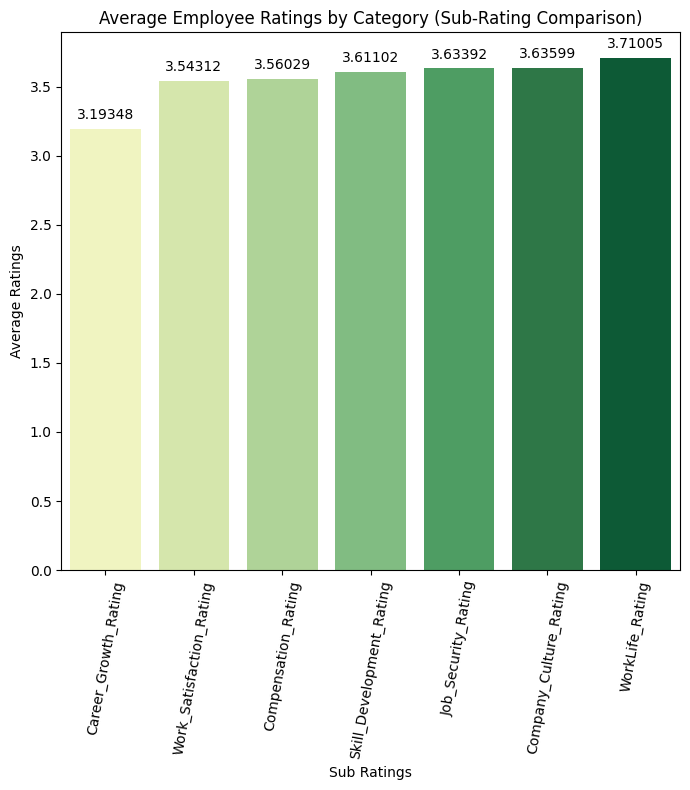

In [50]:
plt.figure(figsize=(7,8))
plt.title("Average Employee Ratings by Category (Sub-Rating Comparison)")
sns.barplot(x=sub_rat_mean.index,y=sub_rat_mean,palette="YlGn")
plt.xlabel("Sub Ratings")
plt.ylabel("Average Ratings")
plt.xticks(rotation=80)

for container in plt.gca().containers:
    plt.bar_label(container,padding=5)

plt.tight_layout()
plt.show()

**Insights:**

- Work-Life Balance (~3.71) is the highest-rated factor, indicating employees are generally satisfied with their work-life balance.
- Company Culture (~3.63) and Job Security (~3.63) also score high, showing positive work environments and stability.
- Skill Development (~3.61) and Compensation (~3.56) fall in the mid-range, suggesting moderate satisfaction in learning opportunities and pay.
- Work Satisfaction (~3.54) is slightly lower, indicating that overall job fulfillment could be improved.
- Career Growth (~3.19) is the lowest-rated factor, highlighting that employees feel limited growth opportunities.
- Overall, employees are happier with stability and balance, but less satisfied with long-term growth and career progression.

#### **3.2.3 Which Top-10 industry has the best Work Life Balance**

In [51]:
industry_workLife_rating = company_df.groupby("Industry")["WorkLife_Rating"].mean().sort_values(ascending=False).head(10)
industry_workLife_rating

Industry
Fitness & Wellness     4.150000
Non-Profit             4.100000
Oil & Gas              4.033333
Defence & Aerospace    4.030000
Railways               4.000000
Government             3.975000
Power                  3.953333
Sports & Recreation    3.950000
Agriculture            3.900000
Waste Management       3.900000
Name: WorkLife_Rating, dtype: float64

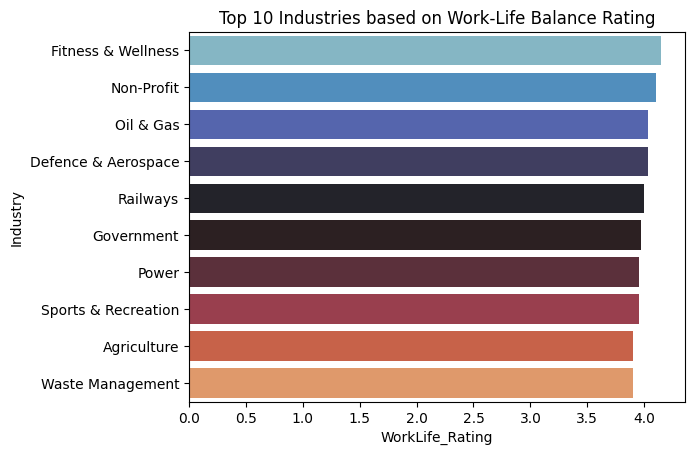

In [52]:

plt.title("Top 10 Industries based on Work-Life Balance Rating")
sns.barplot(x=industry_workLife_rating,y=industry_workLife_rating.index,palette="icefire")
plt.show()

**Insights:**

- Fitness & Wellness (~4.15) and Non-Profit (~4.10) have the highest work-life balance, indicating employees in these sectors experience less stress and better personal time.
- Oil & Gas (~4.03) and Defence & Aerospace (~4.03) also show strong work-life balance, suggesting that structured and stable industries provide better working conditions.
- Railways (~4.00) and Government (~3.97) maintain high ratings, reinforcing that public sector jobs are associated with better balance and stability.
- Industries like Power, Agriculture, and Waste Management (~3.9–3.95) still offer good balance, though slightly lower than the top performers.
- Overall, these industries are mostly stability-focused or essential services, which tend to provide predictable work schedules and lower work pressure.

#### **3.2.4 Which Top-10 Industry has the best Career Growth**

In [53]:
industry_careerGrow_Rat = company_df.groupby("Industry")['Career_Growth_Rating'].mean().sort_values(ascending=False).head(10)
industry_careerGrow_Rat = round(industry_careerGrow_Rat,1)

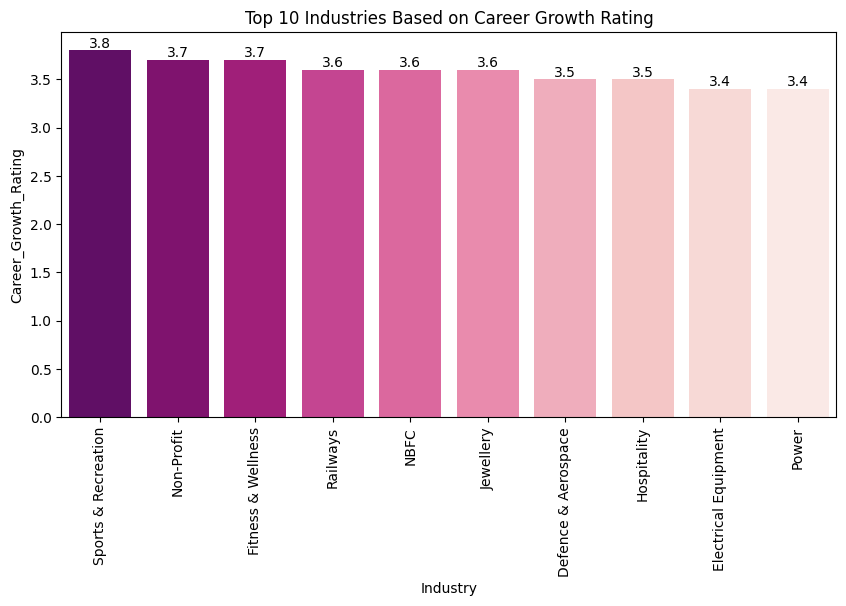

In [54]:
plt.figure(figsize=(10,5))
plt.title("Top 10 Industries Based on Career Growth Rating")
sns.barplot(x=industry_careerGrow_Rat.index,y=industry_careerGrow_Rat,palette="RdPu_r")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.xticks(rotation=90)
plt.show()

**Insights:**
- Sports & Recreation (~3.8) has the highest career growth rating, indicating strong opportunities for advancement in this sector.
- Non-Profit and Fitness & Wellness (~3.7) also rank high, suggesting good growth despite being non-traditional corporate sectors.
- Railways, NBFC, and Jewellery (~3.6) show steady growth opportunities, indicating stable but moderate career progression.
- Defence & Aerospace and Hospitality (~3.5) fall slightly lower, suggesting average growth potential.
- Electrical Equipment and Power (~3.4) have the lowest among the top 10, indicating comparatively slower career progression.
- Overall, even the top industries are in the 3.4–3.8 range, meaning career growth satisfaction is moderate across industries, not extremely high.

#### **3.2.5 Does Indian Employee Count affect overall rating**

In [63]:
company_df['Indian_Employee_Count'].corr(company_df['Ratings'])

np.float64(0.06196253222456962)

**Insights:**
- The correlation between Indian Employee Count and Overall Rating is very low (~0.06).
- This indicates almost no relationship between company size and employee satisfaction.
- Larger companies do not necessarily have higher or lower ratings compared to smaller companies.

### **3.3 Correlation and Key Insights**

#### **3.3.1 Which Sub-Rating corelates more with the Overall Rating**

In [55]:
rating_corr = company_df.corr(numeric_only=True)

<Axes: >

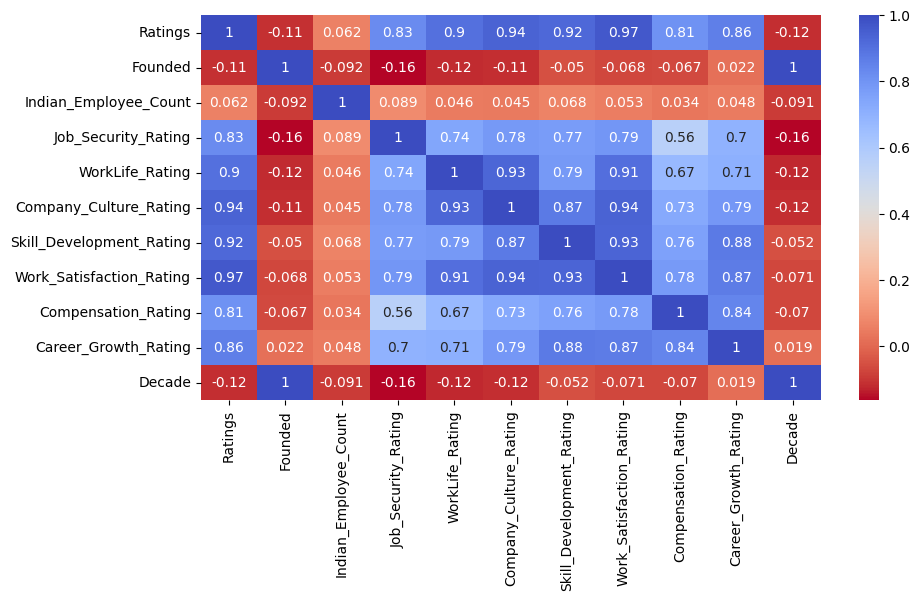

In [56]:
plt.figure(figsize=(10,5))
sns.heatmap(rating_corr,annot=True,cmap="coolwarm_r")

**Insights:**

- From the Heatmap, All the Sub Rating are showing the Positive Corelation with Overall Rating. 
- Work satisfaction rating shows the Highest correlation (0.97) with the Overall Rating.
- Followed by this, Company Culture shows the second highest correlation (0.94) with the overall Rating.
- Whereas Compensation Rating shows the lowerst correlation (0.81) with the Overall Rating.

#### **3.3.2 Is there a correlation between Founded Year and Overall Rating**

**Insights:**
- From the above heatmap, We can clearly see Negative corelation between Founded Year and Overall Rating this suggests that founded year doesn't affect the overall rating.

### **3.4 Geographic Analysis**

#### **3.4.1 Which Indian state has the highest rated companies?**

In [79]:
state_counts = company_df['India_Hq_State'].value_counts()

valid_states = state_counts[state_counts >= 5].index

filtered_df = company_df[company_df['India_Hq_State'].isin(valid_states)]

state_rating = filtered_df.groupby('India_Hq_State')['Ratings'].mean().sort_values(ascending=False)
state_rating

India_Hq_State
Kerala            3.961111
Rajasthan         3.938462
Delhi             3.918421
Gujarat           3.893939
Tamil Nadu        3.801961
Maharashtra       3.800282
Haryana           3.778417
Punjab            3.777778
West Bengal       3.760000
Telangana         3.758333
Uttar Pradesh     3.730159
Karnataka         3.721212
Madhya Pradesh    3.550000
Name: Ratings, dtype: float64

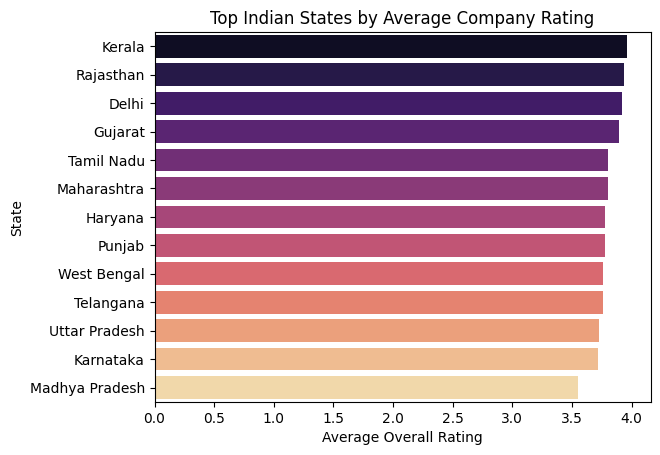

In [83]:
sns.barplot(x=state_rating,y=state_rating.index,palette="magma")
plt.title("Top Indian States by Average Company Rating")
plt.xlabel("Average Overall Rating")
plt.ylabel("State")
plt.show()

**Insights:**
- Kerala (~3.96) has the highest average company rating, indicating the best overall employee satisfaction among the listed states.
- Rajasthan (~3.94) and Delhi (~3.92) also perform very well
- Gujarat (~3.89) ranks next, suggesting relatively high satisfaction levels in industrial regions as well.
- Major corporate states like Maharashtra (~3.80), Tamil Nadu (~3.80), and Karnataka (~3.72) show moderate ratings, indicating average employee satisfaction despite having many companies.
- Telangana (~3.76) and West Bengal (~3.76) fall in the mid-range, suggesting balanced but not exceptional work conditions.
- Madhya Pradesh (~3.55) has the lowest rating, indicating comparatively lower employee satisfaction.

#### **3.4.2 Which country has the most global HQs of companies in India**

In [111]:
clean_df = company_df[company_df['Main_Headquarter_Country'] != 'Not Provided']


In [112]:
country_counts = clean_df['Main_Headquarter_Country'].value_counts().head(5)
country_counts

Main_Headquarter_Country
India             1069
United States      247
United Kingdom      34
Germany             27
France              23
Name: count, dtype: int64

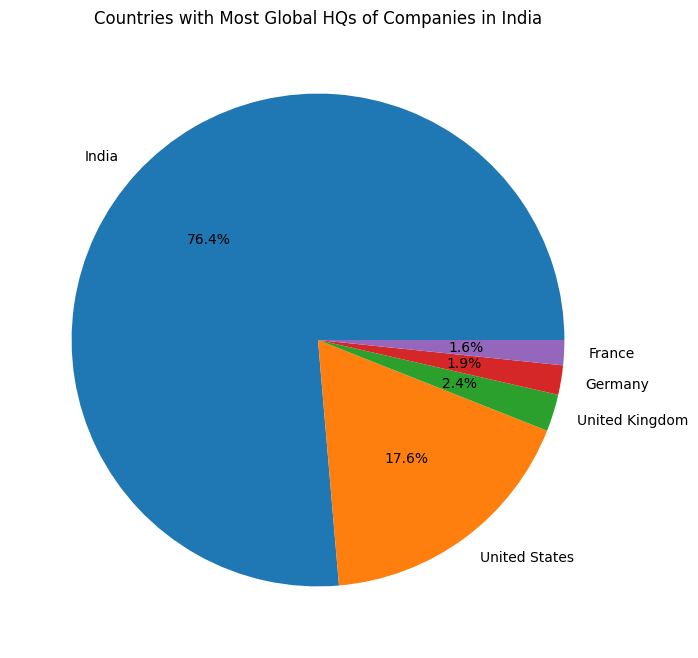

In [113]:
plt.figure(figsize=(8,8))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%')
plt.title("Countries with Most Global HQs of Companies in India")
plt.show()

**Insights:**
- India dominates massively with 1069 HQs → shows strong domestic company base
- United States (247) is a distant second → highest foreign contributor
- United Kingdom (34) + 🇩🇪 Germany + 🇫🇷 France → moderate European presence